<a href="https://colab.research.google.com/github/SamiHotak/invoice-ai/blob/main/notebooks/01_quickstart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# InvoiceAI — Quickstart

Extract structured data from invoices and receipts with **Qwen2.5-VL-3B**.

**Before you start:** `Runtime → Change runtime type → T4 GPU`.

## 1. Check the GPU

In [1]:
!nvidia-smi

Wed Sep 23 06:21:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Get the code

In [2]:
GITHUB_USER = "SamiHotak"  # <- change this
REPO = "invoice-ai"

import os
if not os.path.exists(REPO):
    !git clone https://github.com/SamiHotak/invoice-ai.git
%cd {REPO}
!git pull

Cloning into 'invoice-ai'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 46 (delta 12), reused 13 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 638.04 KiB | 2.14 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/invoice-ai
Already up to date.


## 3. Install requirements

In [3]:
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 870.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 4. Load the model

The first run downloads about 7 GB (takes a few minutes).

If the output is empty or looks like `!!!!!!`, float16 has a problem on this GPU.
Then run `os.environ["INVOICEAI_DTYPE"] = "bfloat16"` **before** this cell, restart the runtime (`Runtime → Restart session`) and run again.

## 5. Run extraction on the sample images

In [4]:
import os, sys, json, time, logging
os.chdir("/content/invoice-ai")
sys.path.insert(0, "/content/invoice-ai")

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

from app.config import settings
from app.extractor import get_extractor

print(settings)
extractor = get_extractor()

start = time.time()
extractor.load()
print(f"Model loaded in {time.time() - start:.1f} s")

Settings(model_name='Qwen/Qwen2.5-VL-3B-Instruct', device='cuda', dtype='float16', max_image_side=1600, min_pixels=200704, max_pixels=1003520, max_new_tokens=1536, pdf_dpi=200, max_pdf_pages=3, ocr_lang='en', ocr_device='cpu', ocr_min_confidence=0.5, match_high_threshold=90.0, match_medium_threshold=70.0)


`torch_dtype` is deprecated! Use `dtype` instead!
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

Model loaded in 110.4 s


Found 3 sample images
sroie_1.jpg


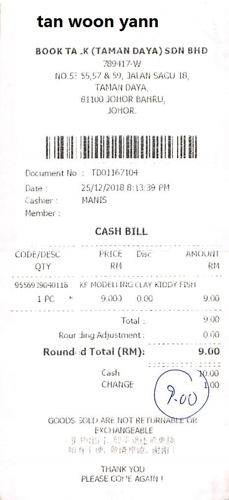

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{
  "vendor_name": "tan woon yann",
  "vendor_address": "BOOK TA .K (TAMAN DAYA) SDN BHD NO.53 55,57 & 59, JALAN SAGU 18 TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.",
  "invoice_number": "TD01167104",
  "invoice_date": "2018-12-25",
  "currency": "MYR",
  "line_items": [
    {
      "description": "KF MODELLING CLAY KIDDY FISH",
      "quantity": 1.0,
      "unit_price": 9.0,
      "total": 9.0
    }
  ],
  "subtotal": 9.0,
  "tax": null,
  "total_amount": 9.0
}
Time: 17.0 s
sroie_2.jpg


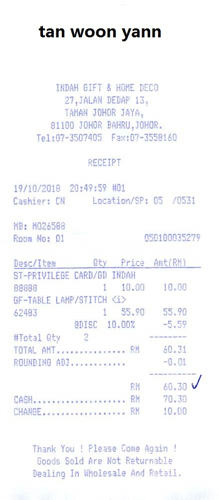

{
  "vendor_name": "INDAH GIFT & HOME DECO",
  "vendor_address": "27,JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JOHOR BAHRU,JOHOR.",
  "invoice_number": "01",
  "invoice_date": "2018-10-19",
  "currency": "MYR",
  "line_items": [
    {
      "description": "ST-PRIIVILEGE CARD/GD INDAH",
      "quantity": 1.0,
      "unit_price": 10.0,
      "total": 10.0
    },
    {
      "description": "GF-TABLE LAMP/STITCH <i>",
      "quantity": 1.0,
      "unit_price": 55.9,
      "total": 55.9
    }
  ],
  "subtotal": 60.31,
  "tax": 0.0,
  "total_amount": 60.3
}
Time: 13.1 s
sroie_3.jpg


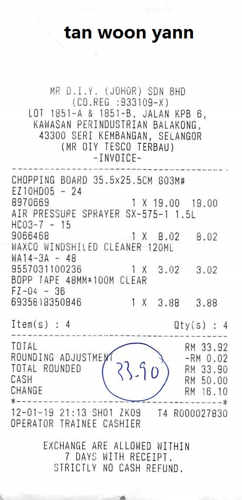

{
  "vendor_name": "MR D.I.Y. (JOHOR) SDN BHD",
  "vendor_address": "LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERINDUSTRIAN BALAKONG, 43300 SERI KEMBANGAN, SELANGOR (MR DIY TESCO TERBAU)",
  "invoice_number": null,
  "invoice_date": "2023-01-19",
  "currency": "MYR",
  "line_items": [
    {
      "description": "CHOPPING BOARD 35.5x25.5CM 603M# EZ10HD05 - 24",
      "quantity": 1.0,
      "unit_price": 19.0,
      "total": 19.0
    },
    {
      "description": "AIR PRESSURE SPRAYER SX-575-1 1.5L HC03-7 - 15",
      "quantity": 1.0,
      "unit_price": 8.02,
      "total": 8.02
    },
    {
      "description": "WAXCO WINDSHILED CLEANER 120ML WA14-3A - 48",
      "quantity": 1.0,
      "unit_price": 3.02,
      "total": 3.02
    },
    {
      "description": "BOPP TAPE 48MM*100M CLEAR FZ-04 - 36",
      "quantity": 1.0,
      "unit_price": 3.88,
      "total": 3.88
    }
  ],
  "subtotal": 33.92,
  "tax": 0.02,
  "total_amount": 33.9
}
Time: 22.2 s


In [5]:
from pathlib import Path
from IPython.display import display
from PIL import Image

from app.extractor import ExtractionError

sample_files = sorted(
    p for p in Path("samples").iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)
print(f"Found {len(sample_files)} sample images")

for path in sample_files[:3]:
    print("=" * 80)
    print(path.name)
    preview = Image.open(path)
    preview.thumbnail((500, 500))
    display(preview)

    start = time.time()
    try:
        invoice = extractor.extract(path)
        print(json.dumps(invoice.model_dump(mode="json"), indent=2, ensure_ascii=False))
    except ExtractionError as exc:
        print(f"FAILED: {exc}")
        print("Raw model output:")
        print(extractor.last_raw_output)
    print(f"Time: {time.time() - start:.1f} s")